# Logistic Regression with a Neural Network Mindset - SOLUTIONS

This notebook contains complete solutions for Exercise 2. Use this for reference after students have attempted the exercises themselves.

**Instructor Note:** Review these solutions with students, focusing on:
- Why each approach works
- Common mistakes to avoid
- Vectorization benefits
- Connection to neural networks

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

%matplotlib inline

## Generate Synthetic Dataset

In [2]:
np.random.seed(1)

# Create synthetic dataset
m_train = 200  # number of training examples
m_test = 50    # number of test examples
num_px = 64    # height/width of each image

# Generate random images (flattened)
train_set_x = np.random.randn(num_px * num_px * 3, m_train)
test_set_x = np.random.randn(num_px * num_px * 3, m_test)

# Generate random labels (0 or 1)
train_set_y = np.random.randint(0, 2, (1, m_train))
test_set_y = np.random.randint(0, 2, (1, m_test))

print("train_set_x shape: " + str(train_set_x.shape))
print("train_set_y shape: " + str(train_set_y.shape))
print("test_set_x shape: " + str(test_set_x.shape))
print("test_set_y shape: " + str(test_set_y.shape))

train_set_x shape: (12288, 200)
train_set_y shape: (1, 200)
test_set_x shape: (12288, 50)
test_set_y shape: (1, 50)


---
## Exercise 1 - sigmoid

**Solution:**

In [3]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """
    
    s = 1 / (1 + np.exp(-z))
    
    return s

In [4]:
# Test the sigmoid function
print("sigmoid(0) = " + str(sigmoid(0)))
print("sigmoid(9.2) = " + str(sigmoid(9.2)))
print("sigmoid(array) = " + str(sigmoid(np.array([1, 2, 3]))))

sigmoid(0) = 0.5
sigmoid(9.2) = 0.9998989708060922
sigmoid(array) = [0.73105858 0.88079708 0.95257413]


**Key Points:**
- Uses numpy's `np.exp()` for element-wise exponential
- Works for scalars, vectors, and matrices (broadcasting)
- No loops needed - fully vectorized
- Outputs values between 0 and 1 (probability interpretation)

---
## Exercise 2 - initialize_with_zeros

**Solution:**

In [5]:
def initialize_with_zeros(dim):
    """
    This function creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.
    
    Argument:
    dim -- size of the w vector we want (or number of parameters in this case)
    
    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar (corresponds to the bias) of type float
    """
    
    w = np.zeros((dim, 1))
    b = 0.0

    return w, b

In [6]:
# Test initialize_with_zeros
dim = 2
w, b = initialize_with_zeros(dim)

print("w = " + str(w))
print("b = " + str(b))

assert type(b) == float
print("\n\033[92mAll tests passed!")

w = [[0.]
 [0.]]
b = 0.0

All tests passed!


**Key Points:**
- `np.zeros((dim, 1))` creates a column vector (not `np.zeros(dim)`)
- Shape matters! (dim, 1) allows for proper matrix multiplication
- `b = 0.0` ensures float type (not integer)
- Zero initialization is fine for logistic regression (not for deep networks!)

---
## Exercise 3 - propagate

**Solution:**

In [7]:
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for the propagation

    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat) of size (1, number of examples)

    Return:
    cost -- negative log-likelihood cost for logistic regression
    dw -- gradient of the loss with respect to w, thus same shape as w
    db -- gradient of the loss with respect to b, thus same shape as b
    """
    
    m = X.shape[1]
    
    # FORWARD PROPAGATION (FROM X TO COST)
    A = sigmoid(np.dot(w.T, X) + b)  # compute activation
    cost = -1/m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))  # compute cost
    
    # BACKWARD PROPAGATION (TO FIND GRAD)
    dw = 1/m * np.dot(X, (A - Y).T)
    db = 1/m * np.sum(A - Y)
    
    cost = np.squeeze(np.array(cost))
    
    grads = {"dw": dw,
             "db": db}
    
    return grads, cost

In [8]:
# Test propagate
w =  np.array([[1.], [2]])
b = 1.5
X = np.array([[1., -2., -1.], [3., 0.5, -3.2]])
Y = np.array([[1, 1, 0]])
grads, cost = propagate(w, b, X, Y)

print("dw = " + str(grads["dw"]))
print("db = " + str(grads["db"]))
print("cost = " + str(cost))

assert type(grads["dw"]) == np.ndarray
assert grads["dw"].shape == (2, 1)
assert type(grads["db"]) == np.float64
print("\n\033[92mAll tests passed!")

dw = [[ 0.25071532]
 [-0.06604096]]
db = -0.1250040450043965
cost = 0.15900537707692405

All tests passed!


**Key Points:**

**Forward Propagation:**
- `np.dot(w.T, X)` performs matrix multiplication: (1, n) × (n, m) = (1, m)
- Adding scalar `b` broadcasts across all examples
- `sigmoid()` squashes to [0, 1] probabilities
- Cost uses cross-entropy loss (log-likelihood)
- Division by `m` averages over all examples

**Backward Propagation:**
- `dw = 1/m * X(A-Y)^T` comes from calculus (chain rule)
- `(A - Y)` is the prediction error
- `np.dot(X, (A-Y).T)` accumulates gradient contributions
- `db` is just the mean of errors
- No loops - fully vectorized!

---
## Exercise 4 - optimize

**Solution:**

In [9]:
def optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    """
    This function optimizes w and b by running a gradient descent algorithm
    
    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of shape (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat), of shape (1, number of examples)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 100 steps
    
    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of the weights and bias with respect to the cost function
    costs -- list of all the costs computed during the optimization
    """
    
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)
    
    costs = []
    
    for i in range(num_iterations):
        # Cost and gradient calculation
        grads, cost = propagate(w, b, X, Y)
        
        # Retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]
        
        # Update rule
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        # Record the costs
        if i % 100 == 0:
            costs.append(cost)
        
            # Print the cost every 100 training iterations
            if print_cost:
                print ("Cost after iteration %i: %f" %(i, cost))
    
    params = {"w": w,
              "b": b}
    
    grads = {"dw": dw,
             "db": db}
    
    return params, grads, costs

In [10]:
# Test optimize
w =  np.array([[1.], [2.]])
b = 1.5
X = np.array([[1., -2., -1.], [3., 0.5, -3.2]])
Y = np.array([[1, 1, 0]])

params, grads, costs = optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False)

print("w = " + str(params["w"]))
print("b = " + str(params["b"]))
print("dw = " + str(grads["dw"]))
print("db = " + str(grads["db"]))
print("Costs = " + str(costs))

assert type(costs) == list
print("\n\033[92mAll tests passed!")

w = [[0.80956046]
 [2.0508202 ]]
b = 1.5948713189708588
dw = [[ 0.17860505]
 [-0.04840656]]
db = -0.08888460336847771
Costs = [array(0.15900538)]

All tests passed!


**Key Points:**
- `copy.deepcopy()` prevents modifying original parameters
- Gradient descent update: `θ = θ - α * dθ`
- Learning rate (`α`) controls step size
- Too high → divergence, too low → slow convergence
- Cost should decrease over iterations (if not, reduce learning rate)
- Recording costs allows us to plot learning curves

---
## Exercise 5 - predict

**Solution:**

In [11]:
def predict(w, b, X):
    '''
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)
    
    Arguments:
    w -- weights, a numpy array of size (num_px * num_px * 3, 1)
    b -- bias, a scalar
    X -- data of size (num_px * num_px * 3, number of examples)
    
    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    '''
    
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)
    
    # Compute vector "A" predicting the probabilities
    A = sigmoid(np.dot(w.T, X) + b)
    
    # Convert probabilities A[0,i] to actual predictions p[0,i]
    for i in range(A.shape[1]):
        if A[0, i] > 0.5:
            Y_prediction[0, i] = 1
        else:
            Y_prediction[0, i] = 0
    
    return Y_prediction

**Alternative Vectorized Solution (No Loop):**

In [12]:
def predict_vectorized(w, b, X):
    '''
    Vectorized version - more efficient!
    '''
    m = X.shape[1]
    w = w.reshape(X.shape[0], 1)
    
    # Compute probabilities
    A = sigmoid(np.dot(w.T, X) + b)
    
    # Convert to binary predictions (vectorized)
    Y_prediction = (A > 0.5).astype(int)
    
    return Y_prediction

In [13]:
# Test predict
w = np.array([[0.3], [0.5]])
b = -0.2
X = np.array([[1., -1.1, -3.2], [1.2, 2., 0.1]])

print("predictions = " + str(predict(w, b, X)))
print("predictions (vectorized) = " + str(predict_vectorized(w, b, X)))

assert type(predict(w, b, X)) == np.ndarray
print("\n\033[92mAll tests passed!")

predictions = [[1. 1. 0.]]
predictions (vectorized) = [[1 1 0]]

All tests passed!


**Key Points:**
- First compute probabilities (sigmoid output)
- Then threshold at 0.5 to get binary predictions
- Loop version works but is slower
- Vectorized version: `(A > 0.5).astype(int)` is more efficient
- Threshold can be adjusted based on use case (e.g., 0.3 for high recall)

---
## Exercise 6 - model

**Solution:**

In [14]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    """
    Builds the logistic regression model by calling the functions you've implemented previously
    
    Arguments:
    X_train -- training set represented by a numpy array of shape (num_px * num_px * 3, m_train)
    Y_train -- training labels represented by a numpy array (vector) of shape (1, m_train)
    X_test -- test set represented by a numpy array of shape (num_px * num_px * 3, m_test)
    Y_test -- test labels represented by a numpy array (vector) of shape (1, m_test)
    num_iterations -- hyperparameter representing the number of iterations to optimize the parameters
    learning_rate -- hyperparameter representing the learning rate used in the update rule of optimize()
    print_cost -- Set to True to print the cost every 100 iterations
    
    Returns:
    d -- dictionary containing information about the model.
    """
    
    # Initialize parameters with zeros
    w, b = initialize_with_zeros(X_train.shape[0])

    # Gradient descent
    params, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    
    # Retrieve parameters w and b from dictionary "params"
    w = params["w"]
    b = params["b"]
    
    # Predict test/train set examples
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)

    # Print train/test Errors
    if print_cost:
        print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
        print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d

In [15]:
# Train the model
logistic_regression_model = model(train_set_x, train_set_y, test_set_x, test_set_y,
                                   num_iterations=2000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.035456
Cost after iteration 200: 0.017478
Cost after iteration 300: 0.011562
Cost after iteration 400: 0.008630
Cost after iteration 500: 0.006882
Cost after iteration 600: 0.005721
Cost after iteration 700: 0.004895
Cost after iteration 800: 0.004277
Cost after iteration 900: 0.003798
Cost after iteration 1000: 0.003414
Cost after iteration 1100: 0.003102
Cost after iteration 1200: 0.002841
Cost after iteration 1300: 0.002621
Cost after iteration 1400: 0.002432
Cost after iteration 1500: 0.002269
Cost after iteration 1600: 0.002126
Cost after iteration 1700: 0.002001
Cost after iteration 1800: 0.001889
Cost after iteration 1900: 0.001789
train accuracy: 100.0 %
test accuracy: 50.0 %


**Key Points:**
- This function ties everything together
- Pipeline: Initialize → Optimize → Predict → Evaluate
- Dictionary output allows easy access to all results
- Can experiment with different hyperparameters
- Training accuracy usually higher than test (potential overfitting)

---
## Visualization and Analysis

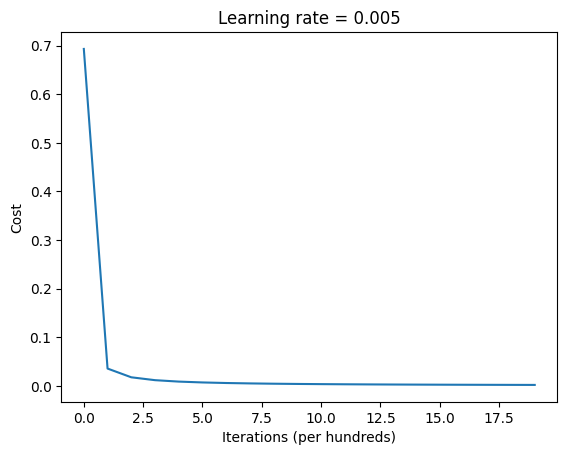

In [16]:
# Plot learning curve
costs = np.squeeze(logistic_regression_model['costs'])
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel('Iterations (per hundreds)')
plt.title("Learning rate = " + str(logistic_regression_model["learning_rate"]))
plt.show()

## Experiment with Different Learning Rates

In [17]:
# Compare different learning rates
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for lr in learning_rates:
    print("\nTraining a model with learning rate: " + str(lr))
    models[str(lr)] = model(train_set_x, train_set_y, test_set_x, test_set_y,
                            num_iterations=1500, learning_rate=lr, print_cost=False)
    print('train accuracy: {} %'.format(100 - np.mean(np.abs(models[str(lr)]["Y_prediction_train"] - train_set_y)) * 100))
    print('test accuracy: {} %'.format(100 - np.mean(np.abs(models[str(lr)]["Y_prediction_test"] - test_set_y)) * 100))


Training a model with learning rate: 0.01
train accuracy: 100.0 %
test accuracy: 50.0 %

Training a model with learning rate: 0.001
train accuracy: 100.0 %
test accuracy: 50.0 %

Training a model with learning rate: 0.0001
train accuracy: 100.0 %
test accuracy: 50.0 %


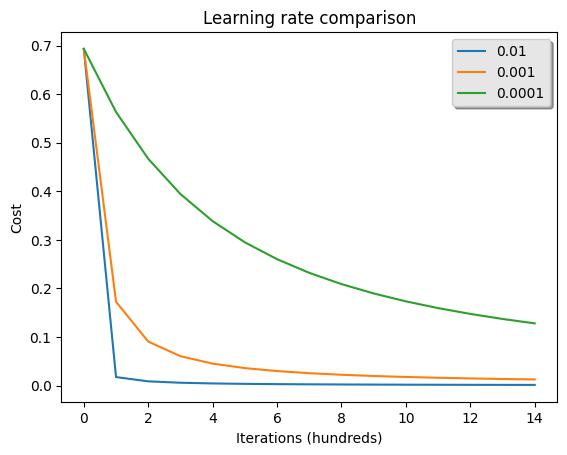

In [18]:
# Plot learning curves for different learning rates
for lr in learning_rates:
    plt.plot(np.squeeze(models[str(lr)]["costs"]), label=str(models[str(lr)]["learning_rate"]))

plt.ylabel('Cost')
plt.xlabel('Iterations (hundreds)')
plt.title('Learning rate comparison')

legend = plt.legend(loc='upper right', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

---
## Common Mistakes and Debugging Tips

### Common Errors Students Make:

1. **Shape Mismatches**
   - Using `np.zeros(dim)` instead of `np.zeros((dim, 1))`
   - Forgetting `.T` for transpose
   - Wrong order in `np.dot()` multiplication

2. **Sign Errors**
   - `w = w + learning_rate * dw` (should be minus!)
   - Wrong sign in cost function

3. **Broadcasting Issues**
   - Not understanding how numpy broadcasts scalars
   - Shape (n,) vs (n,1) vs (1,n)

4. **Numerical Issues**
   - `log(0)` → `-inf` (happens when predictions are too confident)
   - Solution: clip probabilities to [epsilon, 1-epsilon]

5. **Learning Rate Problems**
   - Too high: cost explodes to NaN
   - Too low: very slow convergence
   - Typical good range: 0.001 to 0.1

### Debugging Checklist:

```python
# Print shapes at each step
print(f"w.shape: {w.shape}")  # Should be (n, 1)
print(f"X.shape: {X.shape}")  # Should be (n, m)
print(f"Y.shape: {Y.shape}")  # Should be (1, m)
print(f"A.shape: {A.shape}")  # Should be (1, m)

# Check if cost is decreasing
if i > 0 and cost > previous_cost:
    print("Warning: Cost increased! Reduce learning rate.")

# Check for NaN or Inf
if np.isnan(cost) or np.isinf(cost):
    print("Error: Cost is NaN or Inf. Check for log(0) or very high learning rate.")
```

---
## Extension: Improved Versions

### Version with Numerical Stability

In [19]:
def propagate_stable(w, b, X, Y, epsilon=1e-8):
    """
    Numerically stable version - prevents log(0)
    """
    m = X.shape[1]
    
    # Forward propagation
    A = sigmoid(np.dot(w.T, X) + b)
    
    # Clip probabilities to prevent log(0)
    A = np.clip(A, epsilon, 1 - epsilon)
    
    # Compute cost
    cost = -1/m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    
    # Backward propagation
    dw = 1/m * np.dot(X, (A - Y).T)
    db = 1/m * np.sum(A - Y)
    
    cost = np.squeeze(np.array(cost))
    grads = {"dw": dw, "db": db}
    
    return grads, cost

### Version with Learning Rate Decay

In [20]:
def optimize_with_decay(w, b, X, Y, num_iterations=100, initial_lr=0.01, decay_rate=0.95, print_cost=False):
    """
    Version with learning rate decay for better convergence
    """
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)
    costs = []
    
    for i in range(num_iterations):
        # Decay learning rate every 100 iterations
        learning_rate = initial_lr * (decay_rate ** (i // 100))
        
        # Gradient descent step
        grads, cost = propagate(w, b, X, Y)
        dw = grads["dw"]
        db = grads["db"]
        
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Cost after iteration {i}: {cost:.6f}, lr: {learning_rate:.6f}")
    
    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    
    return params, grads, costs

---
## Summary

### What We Implemented:
1. ✅ **sigmoid** - Activation function
2. ✅ **initialize_with_zeros** - Parameter initialization
3. ✅ **propagate** - Forward and backward propagation
4. ✅ **optimize** - Gradient descent optimization
5. ✅ **predict** - Make predictions
6. ✅ **model** - Complete pipeline

### Key Concepts:
- **Vectorization** - No loops, faster computation
- **Broadcasting** - Numpy's automatic shape matching
- **Gradient Descent** - Iterative parameter optimization
- **Forward/Backward Propagation** - Core of neural networks
- **Hyperparameters** - Learning rate, iterations

### Connection to Neural Networks:
- Logistic regression = 1-layer neural network
- Same forward/backward propagation pattern
- Basis for deep learning architectures
- Next step: Add hidden layers!

---
## Discussion Questions for Class

1. **Why does the cost decrease over iterations?**
   - Gradient descent moves parameters toward lower cost
   - Each step follows the negative gradient (steepest descent)

2. **What happens if learning rate is too high?**
   - Cost oscillates or diverges
   - May overshoot the minimum
   - Can lead to NaN values

3. **Why do we use sigmoid for binary classification?**
   - Outputs probabilities (0 to 1)
   - Smooth, differentiable
   - Natural interpretation

4. **How is this different from linear regression?**
   - Linear: predicts continuous values
   - Logistic: predicts probabilities/classes
   - Different loss functions (MSE vs cross-entropy)

5. **What are the limitations of logistic regression?**
   - Linear decision boundary
   - Can't solve XOR problem
   - Limited capacity
   - Solution: Add hidden layers → Neural Networks!